In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["figure.dpi"] = 120

In [18]:
# 데이터 불러오기
train = pd.read_csv('datas/train.csv', encoding='utf-8')
test_df = pd.read_csv('datas/test.csv', encoding='utf-8')
sample_submission_df = pd.read_csv('datas/sample_submission.csv', encoding='utf-8')

In [19]:
train.info()
train.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        3000 non-null   object 
 1   gender                    3000 non-null   object 
 2   age                       3000 non-null   int64  
 3   height                    3000 non-null   float64
 4   weight                    3000 non-null   float64
 5   cholesterol               3000 non-null   float64
 6   systolic_blood_pressure   3000 non-null   int64  
 7   diastolic_blood_pressure  3000 non-null   int64  
 8   glucose                   3000 non-null   float64
 9   bone_density              3000 non-null   float64
 10  activity                  3000 non-null   object 
 11  smoke_status              3000 non-null   object 
 12  medical_history           1711 non-null   object 
 13  family_medical_history    1514 non-null   object 
 14  sleep_pa

ID                             0
gender                         0
age                            0
height                         0
weight                         0
cholesterol                    0
systolic_blood_pressure        0
diastolic_blood_pressure       0
glucose                        0
bone_density                   0
activity                       0
smoke_status                   0
medical_history             1289
family_medical_history      1486
sleep_pattern                  0
edu_level                    607
mean_working                1032
stress_score                   0
dtype: int64

In [20]:
# 결측치 비율
def missing_ratio(df):
    return (df.isna().mean()*100).round(2).rename("%missing")

info = pd.DataFrame({
    "dtype"     : train.dtypes,
    "%missing"  : missing_ratio(train),
    "n_unique"  : train.nunique()
})
display(info.sort_values("%missing", ascending=False))

,dtype,%missing,n_unique
family_medical_history,object,49.53,3
medical_history,object,42.97,3
mean_working,float64,34.40,13
edu_level,object,20.23,3
gender,object,0.00,2
ID,object,0.00,3000
age,int64,0.00,73
height,float64,0.00,1828
weight,float64,0.00,1986
cholesterol,float64,0.00,2215


In [21]:
# 기본 통계
# 수치형 기본 통계
display(train_df.describe().T)

,count,mean,std,min,25%,50%,75%,max
age,3000.0,53.068000,20.672070,17.00,35.0000,53.000,72.0000,89.00
height,3000.0,168.585687,9.351876,141.13,161.8000,168.115,175.3525,195.28
weight,3000.0,72.486680,13.167222,36.32,63.0350,71.240,81.8325,120.88
cholesterol,3000.0,233.910523,24.333434,148.81,216.9275,234.255,250.3775,313.35
systolic_blood_pressure,3000.0,146.144333,15.845310,97.00,135.0000,146.000,158.0000,191.00
diastolic_blood_pressure,3000.0,95.504000,9.895283,60.00,89.0000,95.000,102.0000,124.00
glucose,3000.0,126.467720,18.536844,70.05,113.9125,126.555,139.1800,185.74
bone_density,3000.0,0.933367,0.444783,-0.22,0.5600,0.940,1.3000,2.00
mean_working,1968.0,8.716972,1.628944,4.00,8.0000,9.000,10.0000,16.00
stress_score,3000.0,0.482130,0.288252,0.00,0.2300,0.480,0.7300,1.00


In [22]:
# 범주형 빈도 상위 5개씩
cat_cols = train.select_dtypes("object").columns.drop(["ID"])
for col in cat_cols:
    print(f"\n▶ {col}")
    display(train[col].value_counts().head())


▶ gender


gender
F    1508
M    1492
Name: count, dtype: int64


▶ activity


activity
moderate    1431
light        894
intense      675
Name: count, dtype: int64


▶ smoke_status


...

family_medical_history
diabetes               615
high blood pressure    480
heart disease          419
Name: count, dtype: int64


▶ sleep_pattern


sleep_pattern
normal              1557
sleep difficulty    1019
oversleeping         424
Name: count, dtype: int64


▶ edu_level


edu_level
high school diploma    924
bachelors degree       880
graduate degree        589
Name: count, dtype: int64

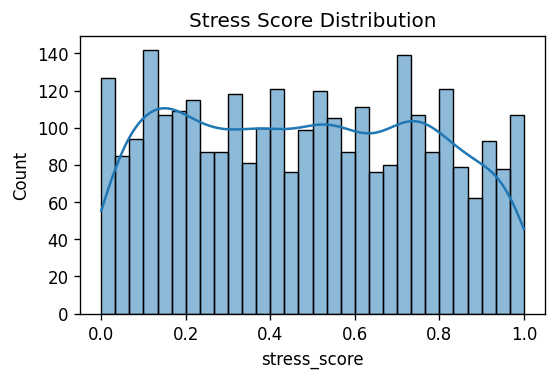

count    3000.000000
mean        0.482130
std         0.288252
min         0.000000
25%         0.230000
50%         0.480000
75%         0.730000
max         1.000000
Name: stress_score, dtype: float64


In [24]:
# ─────────────────────────────────────────────
# 셀 3 : 타깃(stress_score) 분포 확인
# ─────────────────────────────────────────────
plt.figure(figsize=(5,3))
sns.histplot(train["stress_score"], kde=True, bins=30)
plt.title("Stress Score Distribution")
plt.show()

print(train["stress_score"].describe())     